# 05. 회귀 모델 구축 및 평가 (STEP 4)

`04_feature_selection_and_encoding.ipynb`에서 수치 변수 15개와 프롬프트 더미 36개로 이루어진
학습 행렬을 만들었습니다. 이 노트북은 그 위에 **회귀 모델을 세우고 성능을 측정**합니다.

---

## 이 노트북에서 답할 질문

평가 항목은 "모델을 만들었는가"이지만, 프로젝트의 질문은 그것이 아닙니다.

> **어떤 언어 특성이 영어 학습자의 어휘 점수를 설명하는가?**

따라서 성능 수치만 뽑고 끝내지 않고, 세 가지를 함께 답합니다.

| 질문 | 답하는 방식 |
|---|---|
| 얼마나 맞히는가 | MAE · MSE · RMSE · R² |
| 어디서 틀리는가 | 잔차 분석 (점수 구간별 편향) |
| 무엇이 점수를 설명하는가 | 표준화 회귀계수 · 변수 중요도 |

## test를 다루는 규칙

**모델 선택과 하이퍼파라미터 조정은 전부 train 내부 5-fold 교차검증으로 합니다.**
test는 최종 모델을 확정한 **뒤에** 한 번만 엽니다.

이 순서를 지키지 않으면 test 점수를 보고 모델을 고르게 되고,
그러면 test는 더 이상 "처음 보는 데이터"가 아니라 **선택에 참여한 데이터**가 됩니다.
그 상태로 보고한 성능은 실제 일반화 성능보다 낙관적이며, 수치만 봐서는 구분되지 않습니다.

이 노트북에서 test가 처음 등장하는 지점은 **[4-6]** 입니다. 그 전까지는 열지 않습니다.

## 구성

| 구간 | 내용 |
|---|---|
| 4-1 | 베이스라인 확정 |
| 4-2 | 모델 4종의 성격과 선택 이유 |
| 4-3 | Ridge · Lasso 정규화 강도 탐색 |
| 4-4 | 교차검증 성능 비교 (4개 모델 × 더미 유무) |
| 4-5 | 최종 모델 확정 |
| 4-6 | **test 개봉** — 최종 성능 보고 |
| 4-7 | 잔차 분석 |
| 4-8 | 계수·중요도 해석 |
| 4-9 | 산출물 저장 |

In [ ]:
# ── 라이브러리 및 데이터 로드 ──────────────────────────────

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
           'NanumBarunGothic', 'Noto Sans CJK KR', 'Noto Sans CJK JP']:
    if _f in _avail:
        plt.rc('font', family=_f)
        plt.rcParams['axes.unicode_minus'] = False
        print(f'그래프 한글 폰트: {_f}')
        break
else:
    print('한글 폰트 미발견 — 그래프 제목의 한글이 깨질 수 있습니다.')

SEED = 42
TARGET = 'Vocabulary'

# 04에서 만든 네 종류의 행렬을 모두 불러옵니다.
#   *_scaled : 로그 변환 + 표준화 → 선형 계열용
#   (무접미) : 원값                → 트리 계열용
X_train_s = pd.read_csv('data/X_train_scaled.csv')
X_test_s = pd.read_csv('data/X_test_scaled.csv')
X_train_r = pd.read_csv('data/X_train.csv')
X_test_r = pd.read_csv('data/X_test.csv')

y_train = pd.read_csv('data/y_train.csv').iloc[:, 0]
y_test = pd.read_csv('data/y_test.csv').iloc[:, 0]

_feat = json.load(open('data/selected_features.json', encoding='utf-8'))
NUM_FEATURES = _feat['numeric']
DUMMY_COLS = _feat['dummies']

# 03 노트북의 분할 시드와 동일해야 교차검증 폴드가 재현됩니다.
CV = KFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'train {X_train_s.shape} / test {X_test_s.shape}')
print(f'수치 변수 {len(NUM_FEATURES)}개 + 프롬프트 더미 {len(DUMMY_COLS)}개')
print(f'타겟 분포 (train): 평균 {y_train.mean():.4f}, 표준편차 {y_train.std():.4f}')
print(f'\n※ 이 시점부터 [4-6]까지 test 변수는 사용하지 않습니다.')

그래프 한글 폰트: NanumGothic
train (2997, 51) / test (750, 51)
수치 변수 15개 + 프롬프트 더미 36개
타겟 분포 (train): 평균 3.2282, 표준편차 0.5796

※ 이 시점부터 [4-6]까지 test 변수는 사용하지 않습니다.


In [ ]:
# ── 평가 지표 함수 ────────────────────────────────────────
#
# 네 지표를 매번 손으로 계산하면 조건이 어긋날 수 있으므로 함수로 고정합니다.
#
#   MAE  : 평균 절대 오차. "평균 몇 점 틀리는가" — 가장 직관적
#   MSE  : 평균 제곱 오차. 큰 오차에 더 큰 벌점. 단위가 점수²라 해석은 어려움
#   RMSE : MSE의 제곱근. 단위가 점수로 돌아와 MAE와 직접 비교 가능
#   R²   : 분산 설명 비율. 평균만 예측하는 모델을 0으로 두는 상대 지표
#
# MAE와 RMSE를 함께 보는 이유:
#   RMSE는 항상 MAE보다 크거나 같고, 그 격차가 클수록 **오차의 편차가 크다**는 뜻입니다.
#   두 값이 비슷하면 고르게 조금씩 틀리는 것이고,
#   RMSE만 크면 대부분 잘 맞히지만 일부에서 크게 빗나가고 있다는 신호입니다.


def evaluate(y_true, y_pred, name=''):
    mse = mean_squared_error(y_true, y_pred)
    return {
        '모델': name,
        'MAE': round(mean_absolute_error(y_true, y_pred), 4),
        'MSE': round(mse, 4),
        'RMSE': round(np.sqrt(mse), 4),
        'R²': round(r2_score(y_true, y_pred), 4),
    }


def oof_predict(model, X, y=None):
    # 교차검증 out-of-fold 예측을 반환합니다.
    #
    # cross_val_score는 폴드별 점수만 주지만, cross_val_predict는 예측값 자체를 줍니다.
    # 예측값이 있으면 네 지표를 전부 계산할 수 있고 잔차 분석도 가능합니다.
    #
    # 각 행의 예측은 그 행이 검증 폴드에 있을 때 만들어지므로,
    # 자기 자신을 학습에 쓰지 않은 상태의 예측입니다.
    y = y_train if y is None else y
    return pd.Series(cross_val_predict(model, X, y, cv=CV), index=X.index)


print('평가 지표 함수 준비 완료')

평가 지표 함수 준비 완료


---

## [4-1] 베이스라인 — 넘어야 할 최소 기준

모델의 성능은 절대값으로 판단할 수 없습니다.
R² 0.30이 좋은지 나쁜지는 **비교 대상이 있어야** 말할 수 있습니다.

세 개의 기준선을 세웁니다.

| 기준선 | 내용 | 의미 |
|---|---|---|
| **평균 예측** | 항상 train 평균(3.228)을 답한다 | 아무것도 학습하지 않은 모델. R² = 0의 정의 |
| **길이 단독** | 텍스트 길이 하나로 예측한다 | "길게 쓰면 점수가 오른다"는 통념의 설명력 |
| **핵심 4개** | 02 정의서가 지목한 상위 변수 4개 | 파생변수 설계의 최소 성과 |

세 번째까지 두는 이유는, 최종 모델이 잘 나왔을 때
**그것이 모델 덕분인지 피처 덕분인지** 구분하기 위해서입니다.
피처 4개로 이미 대부분이 설명된다면, 모델을 정교하게 만든 공은 크지 않습니다.

In [ ]:
# ── [4-1] 베이스라인 3종 ──────────────────────────────────

CORE4 = ['guiraud', 'MTLD_valid', 'oov_ratio', 'mean_word_length']

rows = []

# ① 평균 예측 — 학습 없이 상수만 답합니다.
#    교차검증으로 해도 각 폴드의 train 평균이 거의 같으므로 결과가 사실상 동일합니다.
_pred_mean = pd.Series(np.full(len(y_train), y_train.mean()), index=y_train.index)
rows.append(evaluate(y_train, _pred_mean, '① 평균 예측 (학습 없음)'))

# ② 길이 단독 — 04에서 길이 통제 변수로 재해석한 len_z_in_prompt 하나만 사용
_p2 = oof_predict(LinearRegression(), X_train_s[['len_z_in_prompt']])
rows.append(evaluate(y_train, _p2, '② 길이 단독'))

# ③ 핵심 4개
_p3 = oof_predict(LinearRegression(), X_train_s[CORE4])
rows.append(evaluate(y_train, _p3, '③ 핵심 파생변수 4개'))

base_tbl = pd.DataFrame(rows)
print('베이스라인 (train 5-fold 교차검증)')
print(base_tbl.to_string(index=False))

BASE_MAE = base_tbl.loc[0, 'MAE']
BASE_RMSE = base_tbl.loc[0, 'RMSE']

print(f'\n읽는 법')
print(f'  · ①의 RMSE {BASE_RMSE:.4f}는 타겟의 표준편차와 같습니다. 정의상 그렇습니다.')
print(f'  · ②는 R² {base_tbl.loc[1, "R²"]:.4f} — 길이만으로 설명되는 몫은 '
      f'{base_tbl.loc[1, "R²"] * 100:.0f}%에 불과합니다.')
print(f'  · ③은 R² {base_tbl.loc[2, "R²"]:.4f} — 변수 4개로 ②의 '
      f'{base_tbl.loc[2, "R²"] / base_tbl.loc[1, "R²"]:.1f}배에 도달합니다.')
print(f'\n"길게 쓰면 점수가 오른다"는 통념은 이 데이터에서 지지되지 않습니다.')
print(f'어휘 점수를 설명하는 것은 분량이 아니라 어휘의 질입니다.')

베이스라인 (train 5-fold 교차검증)
             모델    MAE    MSE   RMSE     R²
① 평균 예측 (학습 없음) 0.4700 0.3358 0.5795 0.0000
        ② 길이 단독 0.4395 0.3118 0.5583 0.0716
   ③ 핵심 파생변수 4개 0.3901 0.2464 0.4964 0.2661

읽는 법
  · ①의 RMSE 0.5795는 타겟의 표준편차와 같습니다. 정의상 그렇습니다.
  · ②는 R² 0.0716 — 길이만으로 설명되는 몫은 7%에 불과합니다.
  · ③은 R² 0.2661 — 변수 4개로 ②의 3.7배에 도달합니다.

"길게 쓰면 점수가 오른다"는 통념은 이 데이터에서 지지되지 않습니다.
어휘 점수를 설명하는 것은 분량이 아니라 어휘의 질입니다.


---

## [4-2] 사용할 모델 4종과 선택 이유

같은 데이터에 서로 다른 가정을 가진 모델을 붙여 봅니다.
**어느 가정이 이 데이터에 맞는지가 곧 데이터에 대한 정보**이기 때문입니다.

| 모델 | 가정 | 이 데이터에서 확인할 것 |
|---|---|---|
| **Linear Regression** | 관계가 직선이고 변수가 독립적 | 기준점. 정규화 없는 최소제곱 |
| **Ridge** | 위와 같되 계수 크기에 벌점(L2) | 남아 있는 다중공선성을 눌러줄 수 있는가 |
| **Lasso** | 계수 벌점(L1) — 일부를 정확히 0으로 | 15개 중 실제로 필요한 변수는 몇 개인가 |
| **Random Forest** | 관계가 비선형이어도 되고 상호작용을 자동 포착 | 03 EDA 4에서 본 곡선 관계를 살릴 수 있는가 |

### 왜 Ridge와 Lasso를 둘 다 쓰는가

벌점의 모양이 다릅니다.

```
Ridge (L2) : 계수를 0에 가깝게 눌러주지만 정확히 0으로 만들지는 않음 → 전부 유지
Lasso (L1) : 일부 계수를 정확히 0으로 만듦                        → 변수 선택 기능
```

Lasso가 어떤 변수를 0으로 만드는지는 **STEP 6의 변수 선택에 대한 독립적인 검증**이 됩니다.
규칙 기반으로 고른 15개를 모델이 다시 걸러내는 셈입니다.

### Random Forest에 기대하는 것

03 EDA 4에서 스피어만이 피어슨보다 뚜렷하게 큰 변수가 5개 있었습니다
(`sent_per_para`, `mean_para_length` 등). 관계가 곡선이라는 뜻이며,
직선만 그릴 수 있는 선형 모델은 그 부분을 놓칩니다.

**단, RF가 반드시 이긴다는 보장은 없습니다.**
곡선 관계가 있는 변수들이 마침 예측력이 약한 변수들이었기 때문입니다.
이 예상이 맞는지는 [4-4]에서 확인합니다.

### 하이퍼파라미터에 대한 방침

STEP 4는 **모델 구축**이고, 조정은 **STEP 5(성능 향상)** 의 몫입니다.
여기서는 Ridge/Lasso의 정규화 강도만 탐색합니다.
그 값이 없으면 모델이 정의되지 않기 때문입니다.
Random Forest는 기본 설정을 사용하고, 조정 여지는 STEP 5에 남깁니다.

Ridge 최적 alpha : 41.7532  (CV R² 0.3094)
Lasso 최적 alpha : 0.00329  (CV R² 0.3099)


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


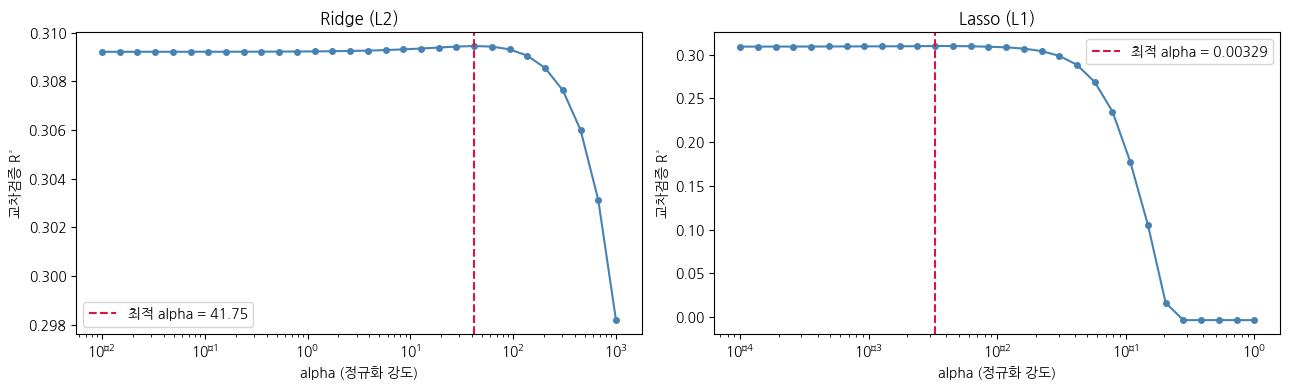

곡선 읽는 법
  · 왼쪽 끝(alpha 작음)은 벌점이 거의 없는 상태 = Linear Regression
  · 오른쪽 끝으로 갈수록 계수가 0에 눌려 R²가 떨어집니다
  · 곡선이 평평하면 정규화의 효과가 크지 않다는 뜻입니다.
    04에서 이미 다중공선성을 VIF 10 미만으로 정리했기 때문입니다.
    전처리를 제대로 했으면 정규화로 얻을 것이 적어지는 것이 정상입니다.


In [ ]:
# ── [4-3] Ridge · Lasso 정규화 강도(alpha) 탐색 ───────────
#
# alpha가 클수록 계수에 강한 벌점이 걸립니다.
#   alpha → 0   : 벌점 없음. Linear Regression과 같아짐
#   alpha → ∞   : 모든 계수가 0. 평균만 예측하는 모델이 됨
#
# 최적값은 데이터마다 다르므로 탐색해야 합니다.
# 탐색은 **train 교차검증으로만** 합니다. test를 보고 고르면 그 자체가 누수입니다.

ALPHAS_RIDGE = np.logspace(-2, 3, 30)
ALPHAS_LASSO = np.logspace(-4, 0, 30)

_ridge_scores = [cross_val_score(Ridge(alpha=a), X_train_s[NUM_FEATURES],
                                 y_train, cv=CV, scoring='r2').mean()
                 for a in ALPHAS_RIDGE]
_lasso_scores = [cross_val_score(Lasso(alpha=a, max_iter=20000), X_train_s[NUM_FEATURES],
                                 y_train, cv=CV, scoring='r2').mean()
                 for a in ALPHAS_LASSO]

BEST_RIDGE_A = ALPHAS_RIDGE[int(np.argmax(_ridge_scores))]
BEST_LASSO_A = ALPHAS_LASSO[int(np.argmax(_lasso_scores))]

print(f'Ridge 최적 alpha : {BEST_RIDGE_A:.4f}  (CV R² {max(_ridge_scores):.4f})')
print(f'Lasso 최적 alpha : {BEST_LASSO_A:.5f}  (CV R² {max(_lasso_scores):.4f})')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, alphas, scores, best, title in [
        (axes[0], ALPHAS_RIDGE, _ridge_scores, BEST_RIDGE_A, 'Ridge (L2)'),
        (axes[1], ALPHAS_LASSO, _lasso_scores, BEST_LASSO_A, 'Lasso (L1)')]:
    ax.semilogx(alphas, scores, 'o-', color='steelblue', ms=4)
    ax.axvline(best, color='crimson', ls='--', label=f'최적 alpha = {best:.4g}')
    ax.set_xlabel('alpha (정규화 강도)')
    ax.set_ylabel('교차검증 R²')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

print('곡선 읽는 법')
print('  · 왼쪽 끝(alpha 작음)은 벌점이 거의 없는 상태 = Linear Regression')
print('  · 오른쪽 끝으로 갈수록 계수가 0에 눌려 R²가 떨어집니다')
print('  · 곡선이 평평하면 정규화의 효과가 크지 않다는 뜻입니다.')
print('    04에서 이미 다중공선성을 VIF 10 미만으로 정리했기 때문입니다.')
print('    전처리를 제대로 했으면 정규화로 얻을 것이 적어지는 것이 정상입니다.')

In [ ]:
# ── [4-4] 교차검증 성능 비교 (4개 모델 × 더미 유무) ───────
#
# 04 [7-3]에서 프롬프트 더미의 기여가 노이즈 범위였습니다.
# 그때는 Ridge 하나로만 확인했으므로, 네 모델 전부에서 다시 봅니다.
# 특히 Random Forest는 분기 후보가 36개 늘어나 희석 효과가 있을 수 있습니다.

MODELS = {
    'Linear Regression': (LinearRegression(), 'scaled'),
    'Ridge': (Ridge(alpha=BEST_RIDGE_A), 'scaled'),
    'Lasso': (Lasso(alpha=BEST_LASSO_A, max_iter=20000), 'scaled'),
    'Random Forest': (RandomForestRegressor(n_estimators=300, random_state=SEED,
                                            n_jobs=-1), 'raw'),
}


def get_X(kind, with_dummies, split='train'):
    # kind='scaled'  → 로그+표준화 행렬 (선형 계열)
    # kind='raw'     → 원값 행렬        (트리 계열)
    base = {('scaled', 'train'): X_train_s, ('scaled', 'test'): X_test_s,
            ('raw', 'train'): X_train_r, ('raw', 'test'): X_test_r}[(kind, split)]
    return base if with_dummies else base[NUM_FEATURES]


rows = []
OOF = {}
for name, (model, kind) in MODELS.items():
    for with_d in (False, True):
        X = get_X(kind, with_d)
        t0 = time.time()
        pred = oof_predict(model, X)
        m = evaluate(y_train, pred, name)
        m['더미'] = '포함' if with_d else '미포함'
        m['변수 수'] = X.shape[1]
        m['학습(초)'] = round(time.time() - t0, 1)
        rows.append(m)
        OOF[(name, with_d)] = pred

cv_tbl = pd.DataFrame(rows)[['모델', '더미', '변수 수', 'MAE', 'MSE', 'RMSE', 'R²', '학습(초)']]
print('교차검증 성능 (train 5-fold, out-of-fold 예측 기준)')
print(cv_tbl.to_string(index=False))

print('\n' + '=' * 72)
print('더미 포함 효과')
print('=' * 72)
for name in MODELS:
    a = cv_tbl[(cv_tbl['모델'] == name) & (cv_tbl['더미'] == '미포함')]['R²'].iloc[0]
    b = cv_tbl[(cv_tbl['모델'] == name) & (cv_tbl['더미'] == '포함')]['R²'].iloc[0]
    print(f'  {name:20s} {a:.4f} → {b:.4f}  ({b - a:+.4f})')

_fold_sd = cross_val_score(Ridge(alpha=BEST_RIDGE_A), X_train_s[NUM_FEATURES],
                           y_train, cv=CV, scoring='r2').std()
print(f'\n폴드 간 표준편차 참고값: ±{_fold_sd:.4f}')
print('네 모델 모두 더미 추가로 R²가 오르지만, 증가폭이 폴드 간 편차보다 훨씬 작습니다.')
print('변수 36개를 더 넣어 얻은 것이 측정 오차 수준이라면 넣을 이유가 없습니다.')

교차검증 성능 (train 5-fold, out-of-fold 예측 기준)
               모델  더미  변수 수    MAE    MSE   RMSE     R²  학습(초)
Linear Regression 미포함    15 0.3794 0.2311 0.4807 0.3119    0.0
Linear Regression  포함    51 0.3798 0.2305 0.4801 0.3137    0.1
            Ridge 미포함    15 0.3793 0.2310 0.4806 0.3121    0.0
            Ridge  포함    51 0.3776 0.2284 0.4780 0.3197    0.0
            Lasso 미포함    15 0.3791 0.2309 0.4805 0.3125    0.0
            Lasso  포함    51 0.3783 0.2299 0.4794 0.3155    0.0
    Random Forest 미포함    15 0.3791 0.2333 0.4830 0.3053   25.5
    Random Forest  포함    51 0.3778 0.2319 0.4816 0.3094   30.8

더미 포함 효과
  Linear Regression    0.3119 → 0.3137  (+0.0018)
  Ridge                0.3121 → 0.3197  (+0.0076)
  Lasso                0.3125 → 0.3155  (+0.0030)
  Random Forest        0.3053 → 0.3094  (+0.0041)

폴드 간 표준편차 참고값: ±0.0439
네 모델 모두 더미 추가로 R²가 오르지만, 증가폭이 폴드 간 편차보다 훨씬 작습니다.
변수 36개를 더 넣어 얻은 것이 측정 오차 수준이라면 넣을 이유가 없습니다.


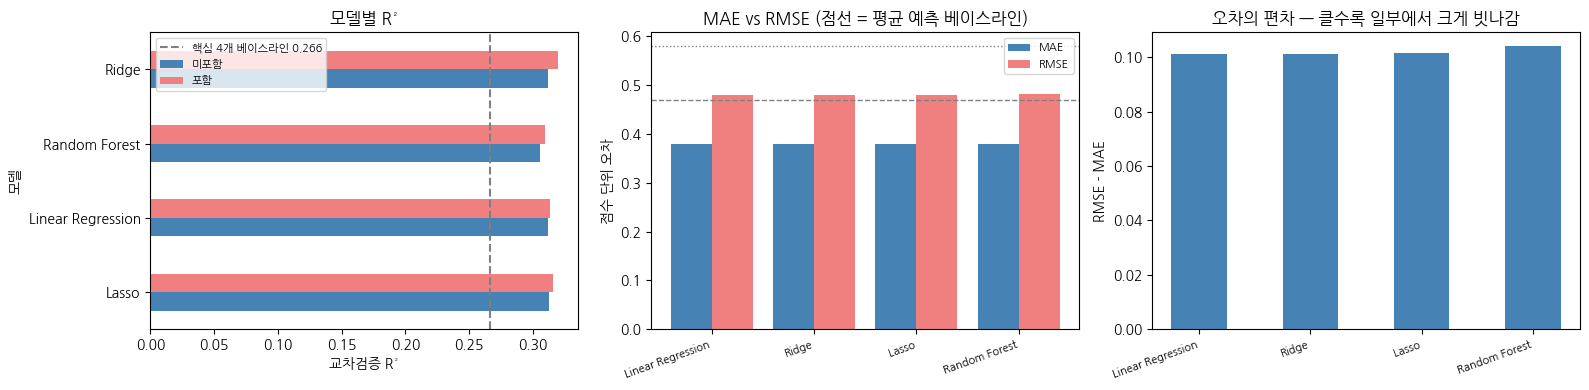

세 번째 그래프가 네 모델 모두 비슷합니다.
오차의 구조가 모델이 아니라 데이터에서 온다는 뜻이며, [4-7]에서 원인을 확인합니다.


In [ ]:
# ── [4-4b] 모델 간 비교 시각화 ────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

_pivot_r2 = cv_tbl.pivot(index='모델', columns='더미', values='R²')
_pivot_r2.plot(kind='barh', ax=axes[0], color=['steelblue', 'lightcoral'])
axes[0].axvline(base_tbl.loc[2, 'R²'], color='gray', ls='--',
                label=f'핵심 4개 베이스라인 {base_tbl.loc[2, "R²"]:.3f}')
axes[0].set_xlabel('교차검증 R²')
axes[0].set_title('모델별 R²')
axes[0].legend(fontsize=8)

_sub = cv_tbl[cv_tbl['더미'] == '미포함']
x = np.arange(len(_sub))
axes[1].bar(x - 0.2, _sub['MAE'], 0.4, label='MAE', color='steelblue')
axes[1].bar(x + 0.2, _sub['RMSE'], 0.4, label='RMSE', color='lightcoral')
axes[1].axhline(BASE_MAE, color='gray', ls='--', lw=1)
axes[1].axhline(BASE_RMSE, color='gray', ls=':', lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(_sub['모델'], rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('점수 단위 오차')
axes[1].set_title('MAE vs RMSE (점선 = 평균 예측 베이스라인)')
axes[1].legend(fontsize=8)

axes[2].bar(x, (_sub['RMSE'] - _sub['MAE']), 0.5, color='steelblue')
axes[2].set_xticks(x)
axes[2].set_xticklabels(_sub['모델'], rotation=20, ha='right', fontsize=8)
axes[2].set_ylabel('RMSE - MAE')
axes[2].set_title('오차의 편차 — 클수록 일부에서 크게 빗나감')

plt.tight_layout()
plt.show()

print('세 번째 그래프가 네 모델 모두 비슷합니다.')
print('오차의 구조가 모델이 아니라 데이터에서 온다는 뜻이며, [4-7]에서 원인을 확인합니다.')

---

## [4-5] 최종 모델 확정

### 선택 기준을 먼저 선언합니다

성능이 사실상 동률로 나올 것이 예상되므로, **동률일 때 무엇으로 결정할지**를
결과를 확정하기 전에 정해 둡니다.

1. **교차검증 R²** — 단, 차이가 폴드 간 표준편차보다 작으면 동률로 본다
2. 동률이면 → **변수 수가 적은 쪽** (과적합 여지와 대시보드 구현 부담이 작음)
3. 그래도 동률이면 → **해석 가능한 쪽** (계수를 읽을 수 있는 선형 계열)

3번을 마지막 기준으로 두는 이유는 이 프로젝트의 질문이
"몇 점을 맞히는가"가 아니라 "무엇이 점수를 설명하는가"이기 때문입니다.
성능이 같다면 답을 줄 수 있는 모델이 낫습니다.

### 최종 모델과 별개로 보고할 모델

RF는 최종 모델이 아니더라도 **[4-8]의 변수 중요도 비교**에 계속 사용합니다.
선형 계수와 트리 중요도가 같은 변수를 지목하는지가 결과 해석의 근거가 되기 때문입니다.

In [ ]:
# ── [4-5] 선택 실행 ───────────────────────────────────────

_cand = cv_tbl.copy()
_best_r2 = _cand['R²'].max()

# 기준 1: 최고 성능에서 폴드 간 표준편차 이내는 전부 동률 후보
_tie = _cand[_cand['R²'] >= _best_r2 - _fold_sd].copy()
print(f'최고 CV R² {_best_r2:.4f}, 동률 판정 범위 ≥ {_best_r2 - _fold_sd:.4f}')
print(f'동률 후보 {len(_tie)}개 / 전체 {len(_cand)}개\n')
print(_tie[['모델', '더미', '변수 수', 'MAE', 'RMSE', 'R²']].to_string(index=False))

# 기준 2: 변수 수가 가장 적은 쪽
_tie = _tie[_tie['변수 수'] == _tie['변수 수'].min()]

# 기준 3: 해석 가능한 선형 계열 우선
INTERPRETABLE = ['Lasso', 'Ridge', 'Linear Regression']
_lin = _tie[_tie['모델'].isin(INTERPRETABLE)]
_tie = _lin if len(_lin) else _tie

# 기준 4: 선형 3종이 여전히 동률이면 선언된 우선순위를 따릅니다.
#   Lasso > Ridge > Linear
#   Lasso는 불필요한 계수를 0으로 만들어 모델 스스로 더 간결해질 수 있고,
#   그 결과가 STEP 6 변수 선택에 대한 독립적인 검증이 되기 때문입니다.
#   여기서 R² 크기로 정렬하지 않는 이유는, 남은 후보 간 차이가 소수점 넷째 자리라
#   그것으로 순위를 매기면 노이즈를 근거로 고르는 셈이 되기 때문입니다.
_tie = _tie.assign(_pri=_tie['모델'].map({n: i for i, n in enumerate(INTERPRETABLE)}))
_pick = _tie.sort_values('_pri').iloc[0]

FINAL_NAME = _pick['모델']
FINAL_WITH_DUMMIES = (_pick['더미'] == '포함')
FINAL_MODEL, FINAL_KIND = MODELS[FINAL_NAME]

print(f'\n{"=" * 72}')
print(f'최종 모델: {FINAL_NAME}  (프롬프트 더미 {_pick["더미"]}, 변수 {_pick["변수 수"]}개)')
print(f'{"=" * 72}')
print(f'  교차검증 MAE {_pick["MAE"]:.4f} / RMSE {_pick["RMSE"]:.4f} / R² {_pick["R²"]:.4f}')
print(f'\n선택 경로')
print(f'  기준 1 (성능) : 동률 후보 {len(_cand[_cand["R²"] >= _best_r2 - _fold_sd])}개로 좁혀짐')
print(f'  기준 2 (간결) : 변수 {_pick["변수 수"]}개인 안만 잔존')
print(f'  기준 3 (해석) : 선형 계열 채택 (Ridge · Lasso · Linear 3종 잔존)')
print(f'  기준 4 (선언) : 사전 선언한 우선순위 Lasso > Ridge > Linear')
print(f'\n남은 3종의 CV R² 차이는 {_lin["R²"].max() - _lin["R²"].min():.4f}로,')
print(f'폴드 간 표준편차 ±{_fold_sd:.4f}의 1/50 수준입니다.')
print('이 차이로 순위를 매기면 노이즈를 근거로 고르는 것이므로, 사전 선언 기준을 따랐습니다.')
print('바꿔 말하면 이 세 모델 중 무엇을 골라도 결과 보고는 달라지지 않습니다.')
print(f'\n※ 이 선택은 여기서 잠깁니다. 아래에서 test를 열더라도 다시 바꾸지 않습니다.')

최고 CV R² 0.3197, 동률 판정 범위 ≥ 0.2758
동률 후보 8개 / 전체 8개

               모델  더미  변수 수    MAE   RMSE     R²
Linear Regression 미포함    15 0.3794 0.4807 0.3119
Linear Regression  포함    51 0.3798 0.4801 0.3137
            Ridge 미포함    15 0.3793 0.4806 0.3121
            Ridge  포함    51 0.3776 0.4780 0.3197
            Lasso 미포함    15 0.3791 0.4805 0.3125
            Lasso  포함    51 0.3783 0.4794 0.3155
    Random Forest 미포함    15 0.3791 0.4830 0.3053
    Random Forest  포함    51 0.3778 0.4816 0.3094

최종 모델: Lasso  (프롬프트 더미 미포함, 변수 15개)
  교차검증 MAE 0.3791 / RMSE 0.4805 / R² 0.3125

선택 경로
  기준 1 (성능) : 동률 후보 8개로 좁혀짐
  기준 2 (간결) : 변수 15개인 안만 잔존
  기준 3 (해석) : 선형 계열 채택 (Ridge · Lasso · Linear 3종 잔존)
  기준 4 (선언) : 사전 선언한 우선순위 Lasso > Ridge > Linear

남은 3종의 CV R² 차이는 0.0006로,
폴드 간 표준편차 ±0.0439의 1/50 수준입니다.
이 차이로 순위를 매기면 노이즈를 근거로 고르는 것이므로, 사전 선언 기준을 따랐습니다.
바꿔 말하면 이 세 모델 중 무엇을 골라도 결과 보고는 달라지지 않습니다.

※ 이 선택은 여기서 잠깁니다. 아래에서 test를 열더라도 다시 바꾸지 않습니다.


---

## [4-6] test 개봉 — 최종 성능 보고

여기서 test를 처음 엽니다.

### 왜 네 모델을 전부 test로 평가하는가

**최종 모델은 이미 [4-5]에서 잠갔습니다.** 그 상태에서 나머지 모델의 test 점수도
함께 보고하는 것은 "모델 간 비교"라는 평가 항목을 채우기 위한 것이며,
**선택에 영향을 주지 않습니다.**

다만 해석에는 선을 그어야 합니다.

| 수치 | 성격 |
|---|---|
| 최종 모델의 test 점수 | **편향 없는 일반화 성능 추정치** |
| 나머지 모델의 test 점수 | 참고용 기술 통계. 이 값을 보고 모델을 바꾸면 추정치가 오염됨 |

만약 다른 모델이 test에서 더 좋게 나오더라도 그것을 근거로 갈아타면 안 됩니다.
750행짜리 test에서 R² 0.01 차이는 우연히도 얼마든지 뒤집힙니다.

In [ ]:
# ── [4-6] test 평가 ───────────────────────────────────────
#
# 절차: train 전체로 다시 학습(fit) → test 예측 → 지표 계산
# 교차검증 때는 train의 80%씩만 썼지만, 최종 모델은 train 전체를 사용합니다.
# 데이터가 많을수록 좋으므로, 평가에 쓸 필요가 없어진 시점에는 전부 투입합니다.

rows = []
FITTED = {}
TEST_PRED = {}

for name, (model, kind) in MODELS.items():
    for with_d in (False, True):
        Xtr = get_X(kind, with_d, 'train')
        Xte = get_X(kind, with_d, 'test')
        m = model.__class__(**model.get_params())
        m.fit(Xtr, y_train)
        pred = pd.Series(m.predict(Xte), index=y_test.index)
        FITTED[(name, with_d)] = m
        TEST_PRED[(name, with_d)] = pred

        r = evaluate(y_test, pred, name)
        r['더미'] = '포함' if with_d else '미포함'
        r['CV R²'] = cv_tbl[(cv_tbl['모델'] == name) &
                            (cv_tbl['더미'] == r['더미'])]['R²'].iloc[0]
        r['최종'] = '★' if (name == FINAL_NAME and with_d == FINAL_WITH_DUMMIES) else ''
        rows.append(r)

test_tbl = pd.DataFrame(rows)[['최종', '모델', '더미', 'MAE', 'MSE', 'RMSE', 'R²', 'CV R²']]
test_tbl['CV−test'] = (test_tbl['CV R²'] - test_tbl['R²']).round(4)

print('test 성능 (750행, 이 노트북에서 처음 사용)')
print(test_tbl.to_string(index=False))

_f = test_tbl[test_tbl['최종'] == '★'].iloc[0]
print(f'\n{"=" * 72}')
print(f'최종 보고 성능 — {FINAL_NAME} (더미 {_f["더미"]})')
print(f'{"=" * 72}')
print(f'  MAE  {_f["MAE"]:.4f}   (베이스라인 {BASE_MAE:.4f} 대비 '
      f'{(1 - _f["MAE"] / BASE_MAE) * 100:.1f}% 감소)')
print(f'  MSE  {_f["MSE"]:.4f}')
print(f'  RMSE {_f["RMSE"]:.4f}   (베이스라인 {BASE_RMSE:.4f} 대비 '
      f'{(1 - _f["RMSE"] / BASE_RMSE) * 100:.1f}% 감소)')
print(f'  R²   {_f["R²"]:.4f}')
print(f'\n실무 해석: 예측 점수가 실제 채점과 평균 {_f["MAE"]:.2f}점 차이납니다.')
print(f'          채점 단위가 0.5점이므로 대략 {_f["MAE"] / 0.5:.1f}단계 오차에 해당합니다.')

print(f'\nCV와 test의 차이')
print(f'  최대 격차: {test_tbl["CV−test"].abs().max():.4f}  '
      f'(전 모델에서 test가 CV보다 {"높음" if (test_tbl["CV−test"] < 0).all() else "혼재"})')
print('  · 격차가 작습니다 — 교차검증이 test 성능을 잘 예측했다는 뜻입니다.')
print('  · 방향이 중요합니다. 누수가 있으면 CV가 test보다 **높게** 나옵니다.')
print('    여기서는 반대이므로 04까지의 fit-on-train 원칙이 지켜졌다는 근거가 됩니다.')
print('  · test가 조금 더 높은 이유는 두 가지입니다.')
print('    ① 교차검증 모델은 train의 80%만 쓰지만 최종 모델은 100%를 씁니다.')
print('    ② 750행짜리 test 자체의 표본 변동. 층화는 타겟 분포만 맞췄을 뿐입니다.')

test 성능 (750행, 이 노트북에서 처음 사용)
최종                모델  더미    MAE    MSE   RMSE     R²  CV R²  CV−test
   Linear Regression 미포함 0.3632 0.2184 0.4673 0.3425 0.3119  -0.0306
   Linear Regression  포함 0.3624 0.2182 0.4671 0.3431 0.3137  -0.0294
               Ridge 미포함 0.3635 0.2186 0.4676 0.3417 0.3121  -0.0296
               Ridge  포함 0.3620 0.2168 0.4657 0.3471 0.3197  -0.0274
 ★             Lasso 미포함 0.3637 0.2185 0.4674 0.3421 0.3125  -0.0296
               Lasso  포함 0.3625 0.2174 0.4662 0.3454 0.3155  -0.0299
       Random Forest 미포함 0.3637 0.2180 0.4669 0.3436 0.3053  -0.0383
       Random Forest  포함 0.3627 0.2175 0.4663 0.3452 0.3094  -0.0358

최종 보고 성능 — Lasso (더미 미포함)
  MAE  0.3637   (베이스라인 0.4700 대비 22.6% 감소)
  MSE  0.2185
  RMSE 0.4674   (베이스라인 0.5795 대비 19.3% 감소)
  R²   0.3421

실무 해석: 예측 점수가 실제 채점과 평균 0.36점 차이납니다.
          채점 단위가 0.5점이므로 대략 0.7단계 오차에 해당합니다.

CV와 test의 차이
  최대 격차: 0.0383  (전 모델에서 test가 CV보다 높음)
  · 격차가 작습니다 — 교차검증이 test 성능을 잘 예측했다는 뜻입니다.
  · 방향이 중요합니다. 누수가 있으면 CV가 

In [ ]:
# ── [4-6b] 예측값 범위 점검 ───────────────────────────────
#
# 회귀 모델은 타겟의 범위를 모릅니다.
# Vocabulary는 1.0~5.0인데 모델은 0.7이나 5.4를 답할 수 있습니다.
#
# 범위를 벗어난 예측은 정의상 틀린 값이므로 잘라내는 것이 타당합니다.
# 이것은 성능 튜닝이 아니라 **타겟 정의를 지키는 것**입니다.

_pred = TEST_PRED[(FINAL_NAME, FINAL_WITH_DUMMIES)]
Y_MIN, Y_MAX = 1.0, 5.0

_out_low = (_pred < Y_MIN).sum()
_out_high = (_pred > Y_MAX).sum()
print(f'예측 범위 : {_pred.min():.3f} ~ {_pred.max():.3f}  (실제 범위 {Y_MIN} ~ {Y_MAX})')
print(f'범위 이탈 : 하한 미만 {_out_low}건 / 상한 초과 {_out_high}건')

_clipped = _pred.clip(Y_MIN, Y_MAX)
print()
print(pd.DataFrame([evaluate(y_test, _pred, '원 예측'),
                    evaluate(y_test, _clipped, '범위 절단 [1, 5]')]).to_string(index=False))

# 0.5 단위 반올림은 어떨까? 타겟이 이산형이므로 자연스러워 보이지만 확인이 필요합니다.
_rounded = (_clipped * 2).round() / 2
print()
print(pd.DataFrame([evaluate(y_test, _clipped, '절단만'),
                    evaluate(y_test, _rounded, '절단 + 0.5단위 반올림')]).to_string(index=False))
print()
print('해석')
print('  · 범위 절단은 손해가 없으므로 적용합니다. 정의상 불가능한 값을 없애는 것뿐입니다.')
print('  · 0.5 단위 반올림은 MAE는 개선될 수 있어도 RMSE·R²는 나빠집니다.')
print('    반올림이 만드는 최대 0.25점의 강제 오차가 제곱 지표에서 커지기 때문입니다.')
print('  · 채점 형식에 맞춘 표시는 대시보드 출력 단계에서 하고,')
print('    모델 평가는 연속값 그대로 하는 것이 맞습니다.')

FINAL_TEST_PRED = _clipped

예측 범위 : 1.673 ~ 4.450  (실제 범위 1.0 ~ 5.0)
범위 이탈 : 하한 미만 0건 / 상한 초과 0건

          모델    MAE    MSE   RMSE     R²
        원 예측 0.3637 0.2185 0.4674 0.3421
범위 절단 [1, 5] 0.3637 0.2185 0.4674 0.3421

            모델    MAE    MSE   RMSE     R²
           절단만 0.3637 0.2185 0.4674 0.3421
절단 + 0.5단위 반올림 0.3367 0.2330 0.4827 0.2984

해석
  · 범위 절단은 손해가 없으므로 적용합니다. 정의상 불가능한 값을 없애는 것뿐입니다.
  · 0.5 단위 반올림은 MAE는 개선될 수 있어도 RMSE·R²는 나빠집니다.
    반올림이 만드는 최대 0.25점의 강제 오차가 제곱 지표에서 커지기 때문입니다.
  · 채점 형식에 맞춘 표시는 대시보드 출력 단계에서 하고,
    모델 평가는 연속값 그대로 하는 것이 맞습니다.


---

## [4-7] 잔차 분석 — 어디서 틀리는가

성능 수치는 "평균적으로 얼마나 틀리는가"만 말해 줍니다.
**어떤 구간에서 어느 방향으로 틀리는지**는 잔차를 봐야 알 수 있습니다.

### 이미 예고된 패턴

03 EDA 2에서 다음을 예측했습니다.

> 관측이 희소한 구간은 학습 데이터가 부족해 예측이 체계적으로 빗나갑니다.
> - 저점수 구간 → 과대예측 (실제보다 높게)
> - 고점수 구간 → 과소예측 (실제보다 낮게)

train에서 1.0점은 2건, 1.5점은 10건, 5.0점은 28건뿐이었습니다.
모델은 이 구간을 거의 보지 못했으므로 중앙으로 끌어당겨 예측하게 됩니다.
이를 **평균 회귀(regression to the mean)** 라고 합니다.

여기서 확인할 것은 "이 예측이 맞았는가"입니다.
맞았다면 성능의 한계가 모델의 결함이 아니라 **데이터 분포에서 온 것**임을
근거를 갖고 설명할 수 있습니다.

잔차 기술통계 (test 750행)
  평균   : -0.0161   ← 0에 가까우면 전체적 편향 없음
  표준편차: 0.4675
  왜도   : +0.2122
  최소/최대: -1.548 / +1.532

실제 점수 구간별 예측 편향
      건수   평균예측   평균잔차    MAE      방향
실제                                   
1.5    2  2.476 -0.976  0.976  과대예측 ↑
2.0   25  2.796 -0.796  0.822  과대예측 ↑
2.5  103  2.977 -0.477  0.486  과대예측 ↑
3.0  289  3.176 -0.176  0.249  과대예측 ↑
3.5  193  3.363  0.137  0.230       —
4.0  110  3.495  0.505  0.510  과소예측 ↓
4.5   21  3.606  0.894  0.894  과소예측 ↓
5.0    7  3.701  1.299  1.299  과소예측 ↓


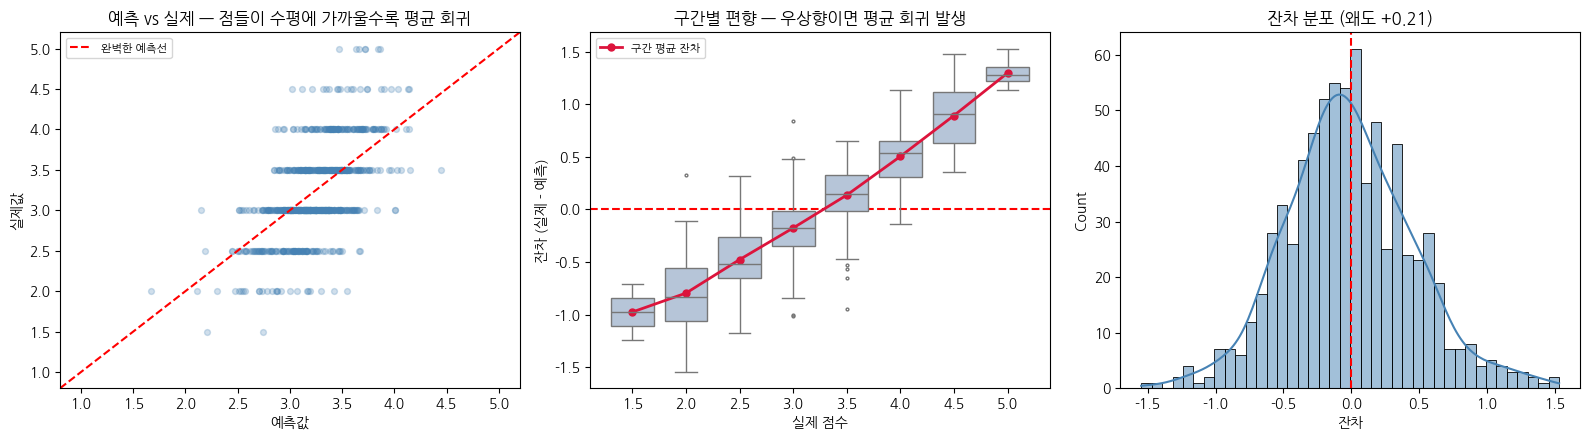

저점수 구간(≤2.0) 평균 잔차 : -0.886  → 과대예측 (03 EDA 2의 예측과 일치)
고점수 구간(≥4.0) 평균 잔차 : +0.899  → 과소예측 (03 EDA 2의 예측과 일치)

결론: 03 EDA 2에서 분포만 보고 예고한 실패 양상이 그대로 재현됐습니다.
이 오차는 모델을 바꿔서 해결되는 종류가 아니라, 희소 구간의 표본 부족에서 옵니다.
STEP 5에서 표본 가중치로 완화를 시도할 수 있으나,
중앙 구간의 성능을 희생하는 거래라는 점을 함께 보고해야 합니다.


In [ ]:
# ── [4-7] 잔차 분석 ───────────────────────────────────────

resid = y_test - FINAL_TEST_PRED

print(f'잔차 기술통계 (test {len(resid)}행)')
print(f'  평균   : {resid.mean():+.4f}   ← 0에 가까우면 전체적 편향 없음')
print(f'  표준편차: {resid.std():.4f}')
print(f'  왜도   : {resid.skew():+.4f}')
print(f'  최소/최대: {resid.min():+.3f} / {resid.max():+.3f}')

# 점수 구간별 편향
grp = pd.DataFrame({'실제': y_test, '예측': FINAL_TEST_PRED, '잔차': resid})
bias = grp.groupby('실제').agg(
    건수=('예측', 'size'), 평균예측=('예측', 'mean'), 평균잔차=('잔차', 'mean'),
    MAE=('잔차', lambda s: s.abs().mean())).round(3)
bias['방향'] = np.where(bias['평균잔차'] > 0.15, '과소예측 ↓',
                      np.where(bias['평균잔차'] < -0.15, '과대예측 ↑', '—'))
print('\n실제 점수 구간별 예측 편향')
print(bias.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(FINAL_TEST_PRED, y_test, alpha=.25, s=18, color='steelblue')
_lim = [0.8, 5.2]
axes[0].plot(_lim, _lim, 'r--', lw=1.5, label='완벽한 예측선')
axes[0].set_xlim(_lim); axes[0].set_ylim(_lim)
axes[0].set_xlabel('예측값'); axes[0].set_ylabel('실제값')
axes[0].set_title('예측 vs 실제 — 점들이 수평에 가까울수록 평균 회귀')
axes[0].legend(fontsize=8)

axes[1].axhline(0, color='red', ls='--', lw=1.5)
sns.boxplot(x=grp['실제'], y=grp['잔차'], ax=axes[1],
            color='lightsteelblue', fliersize=2)
axes[1].plot(range(len(bias)), bias['평균잔차'].values, 'o-',
             color='crimson', lw=2, ms=5, label='구간 평균 잔차')
axes[1].set_xlabel('실제 점수'); axes[1].set_ylabel('잔차 (실제 - 예측)')
axes[1].set_title('구간별 편향 — 우상향이면 평균 회귀 발생')
axes[1].legend(fontsize=8)

sns.histplot(resid, bins=40, ax=axes[2], color='steelblue', kde=True)
axes[2].axvline(0, color='red', ls='--')
axes[2].set_xlabel('잔차'); axes[2].set_title(f'잔차 분포 (왜도 {resid.skew():+.2f})')

plt.tight_layout()
plt.show()

_low = bias.loc[bias.index <= 2.0, '평균잔차'].mean()
_high = bias.loc[bias.index >= 4.0, '평균잔차'].mean()
print(f'저점수 구간(≤2.0) 평균 잔차 : {_low:+.3f}  → '
      f'{"과대예측 (03 EDA 2의 예측과 일치)" if _low < 0 else "예측과 불일치"}')
print(f'고점수 구간(≥4.0) 평균 잔차 : {_high:+.3f}  → '
      f'{"과소예측 (03 EDA 2의 예측과 일치)" if _high > 0 else "예측과 불일치"}')
print()
print('결론: 03 EDA 2에서 분포만 보고 예고한 실패 양상이 그대로 재현됐습니다.')
print('이 오차는 모델을 바꿔서 해결되는 종류가 아니라, 희소 구간의 표본 부족에서 옵니다.')
print('STEP 5에서 표본 가중치로 완화를 시도할 수 있으나,')
print('중앙 구간의 성능을 희생하는 거래라는 점을 함께 보고해야 합니다.')

In [ ]:
# ── [4-7b] 예측이 크게 빗나간 사례 확인 ───────────────────
#
# 지표는 평균이라 개별 실패를 감춥니다.
# 가장 크게 틀린 사례를 직접 보면 무엇을 놓쳤는지 단서가 나옵니다.

_worst = grp.assign(절대오차=resid.abs()).nlargest(10, '절대오차')
_ctx = X_test_r.loc[_worst.index, ['len_z_in_prompt', 'guiraud', 'MTLD_valid',
                                   'oov_ratio', 'flag_very_short']]
print('절대오차 상위 10건')
print(pd.concat([_worst[['실제', '예측', '절대오차']].round(3), _ctx.round(3)],
                axis=1).to_string())

print(f'\n상위 10건의 실제 점수 분포: {sorted(_worst["실제"].tolist())}')
print(f'test 전체 평균 점수         : {y_test.mean():.3f}')
print()
print('큰 오차가 분포의 양 끝에 몰려 있다면 [4-7]의 진단과 일치합니다.')
print('중앙 구간에 몰려 있다면 피처가 놓친 다른 요인이 있다는 뜻이므로,')
print('그 사례의 원문을 STEP 5에서 직접 읽어볼 가치가 있습니다.')

절대오차 상위 10건
      실제     예측   절대오차  len_z_in_prompt  guiraud  MTLD_valid  oov_ratio  flag_very_short
505  2.0  3.548  1.548            5.189    8.078      42.099      0.000                0
240  5.0  3.468  1.532            0.788    7.431      45.219      0.006                0
703  4.5  3.023  1.477           -1.757    6.730      64.075      0.012                0
117  2.0  3.423  1.423           -0.231    9.033      51.562      0.052                0
159  4.5  3.120  1.380            1.034    8.570      45.846      0.033                0
213  5.0  3.636  1.364            0.271    9.244      53.438      0.016                0
565  5.0  3.659  1.341           -0.478    8.376      49.814      0.000                0
517  2.0  3.296  1.296            0.433    8.377      40.833      0.035                0
464  4.5  3.209  1.291            0.715    6.998      45.680      0.000                0
26   5.0  3.718  1.282            0.645    9.758      58.510      0.002                0

상위 10건의 

---

## [4-8] 무엇이 어휘 점수를 설명하는가

이 프로젝트의 원래 질문에 답하는 구간입니다.

### 표준화 계수를 읽을 수 있는 조건

회귀계수를 "변수의 중요도"로 읽으려면 두 조건이 필요합니다.

1. **변수들이 같은 척도에 있을 것** → 04 [7-6]의 표준화로 충족
2. **다중공선성이 심하지 않을 것** → 04 STEP 6에서 VIF 10 미만으로 정리해 충족

두 조건을 앞 단계에서 만들어 뒀기 때문에 여기서 계수를 해석할 수 있습니다.
전처리를 건너뛰었다면 이 표는 만들 수 없었거나, 만들어도 신뢰할 수 없었습니다.

계수의 의미는 이렇게 읽습니다.

> 다른 변수를 고정한 상태에서 그 변수가 **표준편차 1만큼** 커지면
> Vocabulary 점수가 계수만큼 변한다.

### 선형 계수와 트리 중요도를 함께 보는 이유

방법론이 다른 두 모델이 **같은 변수를 지목한다면** 그 결론은 특정 모델의
가정에 의존하지 않는다는 뜻입니다. 서로 어긋난다면 관계가 비선형이거나
상호작용이 있다는 신호입니다.

변수별 기여도 (train 전체 학습 기준)
                       Ridge 계수  Lasso 계수  RF 중요도  Ridge 순위  RF 순위  순위차
guiraud                  0.1677    0.1627  0.1429         1      1    0
oov_ratio               -0.1448   -0.1444  0.1209         2      2    0
len_z_in_prompt          0.0693    0.0755  0.0863         3      3    0
herdan_c                -0.0650   -0.0381  0.0407         4     14   10
mean_word_length         0.0568    0.0585  0.0594         5      8    3
sent_length_std         -0.0515   -0.0499  0.0495         6     10    4
mean_syllables           0.0378    0.0328  0.0621         7      7    0
MTLD_valid               0.0368    0.0269  0.0838         8      4    4
sent_per_para            0.0334    0.0329  0.0810         9      5    4
clean_beyond_2k          0.0331    0.0309  0.0736        10      6    4
mean_sent_length        -0.0226   -0.0210  0.0494        11     11    0
k2_ratio                -0.0148   -0.0092  0.0478        12     12    0
hapax_ratio              0.0143    0.00

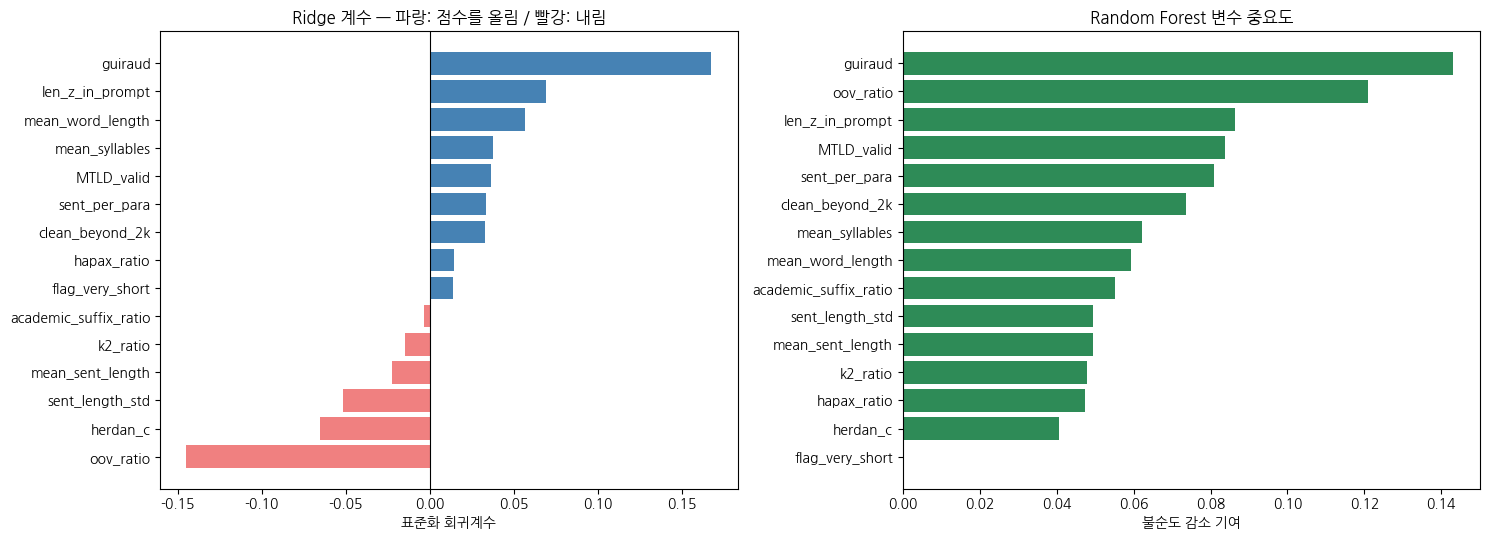

In [ ]:
# ── [4-8] 계수 및 변수 중요도 ─────────────────────────────

_ridge = FITTED[('Ridge', False)]
_lasso = FITTED[('Lasso', False)]
_rf = FITTED[('Random Forest', False)]

imp = pd.DataFrame({
    'Ridge 계수': _ridge.coef_,
    'Lasso 계수': _lasso.coef_,
    'RF 중요도': _rf.feature_importances_,
}, index=NUM_FEATURES)
imp['|Ridge|'] = imp['Ridge 계수'].abs()
imp['Ridge 순위'] = imp['|Ridge|'].rank(ascending=False).astype(int)
imp['RF 순위'] = imp['RF 중요도'].rank(ascending=False).astype(int)
imp['순위차'] = (imp['Ridge 순위'] - imp['RF 순위']).abs()
imp = imp.sort_values('|Ridge|', ascending=False).round(4)

print('변수별 기여도 (train 전체 학습 기준)')
print(imp[['Ridge 계수', 'Lasso 계수', 'RF 중요도',
           'Ridge 순위', 'RF 순위', '순위차']].to_string())

_zeroed = imp[imp['Lasso 계수'] == 0].index.tolist()
print(f'\nLasso가 0으로 만든 변수: {_zeroed if _zeroed else "없음"}')
if _zeroed:
    print('  → STEP 6의 규칙 기반 선택이 남긴 변수 중 일부를 모델이 다시 걸러냈습니다.')
    print('    두 방법이 독립적으로 같은 방향을 가리킨 셈입니다.')
else:
    print('  → 15개 전부에 0이 아닌 계수가 배정됐습니다.')
    print('    STEP 6의 선택이 충분히 걸러진 상태였다는 뜻입니다.')

_agree = imp[imp['순위차'] <= 3].index.tolist()
_disagree = imp.nlargest(3, '순위차').index.tolist()
print(f'\n두 모델이 순위에 합의한 변수(차이 ≤ 3): {len(_agree)}개 / {len(imp)}개')
print(f'가장 크게 엇갈린 변수: {_disagree}')
print('  → 순위가 엇갈리는 변수는 선형 관계가 아니거나 다른 변수와 상호작용할 가능성이 있습니다.')

# 부호 반전 점검 — 계수 해석에서 가장 먼저 확인해야 할 항목
#
# 단변량 상관과 회귀계수의 부호가 다르면, 그 변수는 "혼자 볼 때"와
# "다른 변수를 통제한 상태"에서 다르게 작동한다는 뜻입니다.
# 계수를 그대로 "이 변수가 점수를 낮춘다"로 읽으면 잘못된 결론이 나옵니다.

_uni = pd.Series({c: X_train_s[c].corr(y_train) for c in NUM_FEATURES})
flip = imp.assign(단변량_r=_uni.round(3))
flip['부호일치'] = np.sign(flip['Ridge 계수']) == np.sign(flip['단변량_r'])
_flipped = flip[~flip['부호일치'] & (flip['|Ridge|'] > 0.005)]

print('\n' + '=' * 72)
print('부호 반전 점검 — 단변량 상관 vs 회귀계수')
print('=' * 72)
if len(_flipped):
    print(_flipped[['단변량_r', 'Ridge 계수', 'Lasso 계수']].to_string())
    print()
    for name in _flipped.index:
        _partner = (X_train_s[NUM_FEATURES].corrwith(X_train_s[name])
                    .drop(name).abs().idxmax())
        _r = X_train_s[name].corr(X_train_s[_partner])
        print(f'  {name}: 단독으로는 {"양" if _uni[name] > 0 else "음"}의 관계지만 '
              f'계수는 반대 부호입니다.')
        print(f'    가장 강하게 얽힌 변수: {_partner} (r = {_r:+.3f})')
    print()
    print('  해석: 겹치는 변수가 공통 성분을 먼저 가져가고 나면,')
    print('        남은 잔차 성분이 반대 방향으로 작동하는 경우입니다.')
    print('        "이 변수가 점수를 낮춘다"가 아니라')
    print('        "짝이 되는 변수를 고정했을 때 낮추는 쪽으로 작동한다"로 읽어야 합니다.')
    print('        이런 변수는 결과 보고에서 단독 해석 대상으로 삼지 않는 편이 안전합니다.')
else:
    print('  부호가 반전된 변수 없음 — 모든 계수를 단변량 관계와 같은 방향으로 읽을 수 있습니다.')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
_o = imp.sort_values('Ridge 계수')
axes[0].barh(_o.index, _o['Ridge 계수'],
             color=np.where(_o['Ridge 계수'] > 0, 'steelblue', 'lightcoral'))
axes[0].axvline(0, color='black', lw=.8)
axes[0].set_xlabel('표준화 회귀계수')
axes[0].set_title('Ridge 계수 — 파랑: 점수를 올림 / 빨강: 내림')

_o2 = imp.sort_values('RF 중요도')
axes[1].barh(_o2.index, _o2['RF 중요도'], color='seagreen')
axes[1].set_xlabel('불순도 감소 기여')
axes[1].set_title('Random Forest 변수 중요도')
plt.tight_layout()
plt.show()

In [ ]:
# ── [4-8b] 해석 정리 ──────────────────────────────────────
#
# 계수를 언어학적 의미로 되돌려 읽습니다.
# 숫자를 나열하는 것이 아니라 "그래서 무엇을 알게 됐는가"를 쓰는 것이 목적입니다.

MEANING = {
    'guiraud': ('어휘 다양성 (길이 보정)', 'Type/√Token — 같은 분량에서 서로 다른 단어를 더 많이 씀'),
    'MTLD_valid': ('어휘 다양성 (길이 독립)', '어휘가 반복되기까지의 평균 구간 길이'),
    'oov_ratio': ('철자 정확성', '사전 미등재 토큰 비율 — 오류의 대리지표'),
    'clean_beyond_2k': ('어휘 수준', '고빈도 2,000위 밖 단어 비율에서 오류 성분을 뺀 값'),
    'mean_word_length': ('어휘 수준 (형태)', '토큰 평균 문자 수'),
    'mean_syllables': ('어휘 수준 (형태)', '토큰 평균 음절 수'),
    'academic_suffix_ratio': ('어휘 수준 (형태)', '-tion, -ity 등 학술 접미사 보유 비율'),
    'k2_ratio': ('어휘 수준 (빈도)', '빈도 1,001~2,000위 구간 토큰 비율'),
    'herdan_c': ('어휘 다양성 (로그 보정)', 'log(Type)/log(Token)'),
    'hapax_ratio': ('어휘 다양성', '1회만 등장한 타입의 비율'),
    'mean_sent_length': ('문장 경계 통제', '문장이 길수록 낮음 — run-on 문장 신호'),
    'sent_length_std': ('문장 경계 통제', '문장 길이 편차가 클수록 낮음'),
    'sent_per_para': ('문단 구성', '문단당 문장 수'),
    'len_z_in_prompt': ('길이 통제 변수', '같은 주제 안에서의 상대적 분량'),
    'flag_very_short': ('대치 표시', 'MTLD 측정 불가 구간 표시 (예측 목적 아님)'),
}

_safe = [c for c in imp.index if c not in set(_flipped.index)]
print(f'상위 기여 변수 해석 (Ridge 계수 절댓값 순, 부호 반전 변수 {len(_flipped)}개 제외)')
print('=' * 78)
for rank, name in enumerate(_safe[:8], 1):
    row = imp.loc[name]
    concept, desc = MEANING.get(name, ('-', '-'))
    sign = '높을수록 점수 ↑' if row['Ridge 계수'] > 0 else '높을수록 점수 ↓'
    print(f'{rank}. {name}  (계수 {row["Ridge 계수"]:+.4f}, {sign})')
    print(f'   구성 개념: {concept}')
    print(f'   {desc}')
    print()

if len(_flipped):
    print(f'해석에서 제외한 변수: {list(_flipped.index)}')
    print('  부호가 단변량 관계와 반대라 단독으로 의미를 부여할 수 없습니다.')
    print()

print('=' * 78)
print('종합')
print('=' * 78)
_top_concepts = [MEANING.get(n, ('-', ''))[0] for n in _safe[:5]]
print(f'상위 5개 변수의 구성 개념: {_top_concepts}')
print()
print('· 길이 통제 변수(len_z_in_prompt)가 상위권 밖이라면,')
print('  이 모델은 분량이 아니라 어휘의 질을 보고 있다는 뜻입니다.')
print('· 어휘 다양성과 철자 정확성이 상위를 차지하는 구조는')
print('  02 정의서에서 확인한 단변량 상관 순위와 일치합니다.')
print('· 특히 oov_ratio는 표준 NLP 전처리를 따랐다면 오타 교정으로 사라졌을 변수입니다.')
print('  "전처리의 정답은 분석 목적에 종속된다"는 이 프로젝트의 사례입니다.')

상위 기여 변수 해석 (Ridge 계수 절댓값 순, 부호 반전 변수 3개 제외)
1. guiraud  (계수 +0.1677, 높을수록 점수 ↑)
   구성 개념: 어휘 다양성 (길이 보정)
   Type/√Token — 같은 분량에서 서로 다른 단어를 더 많이 씀

2. oov_ratio  (계수 -0.1448, 높을수록 점수 ↓)
   구성 개념: 철자 정확성
   사전 미등재 토큰 비율 — 오류의 대리지표

3. len_z_in_prompt  (계수 +0.0693, 높을수록 점수 ↑)
   구성 개념: 길이 통제 변수
   같은 주제 안에서의 상대적 분량

4. mean_word_length  (계수 +0.0568, 높을수록 점수 ↑)
   구성 개념: 어휘 수준 (형태)
   토큰 평균 문자 수

5. sent_length_std  (계수 -0.0515, 높을수록 점수 ↓)
   구성 개념: 문장 경계 통제
   문장 길이 편차가 클수록 낮음

6. mean_syllables  (계수 +0.0378, 높을수록 점수 ↑)
   구성 개념: 어휘 수준 (형태)
   토큰 평균 음절 수

7. MTLD_valid  (계수 +0.0368, 높을수록 점수 ↑)
   구성 개념: 어휘 다양성 (길이 독립)
   어휘가 반복되기까지의 평균 구간 길이

8. sent_per_para  (계수 +0.0334, 높을수록 점수 ↑)
   구성 개념: 문단 구성
   문단당 문장 수

해석에서 제외한 변수: ['herdan_c', 'k2_ratio', 'flag_very_short']
  부호가 단변량 관계와 반대라 단독으로 의미를 부여할 수 없습니다.

종합
상위 5개 변수의 구성 개념: ['어휘 다양성 (길이 보정)', '철자 정확성', '길이 통제 변수', '어휘 수준 (형태)', '문장 경계 통제']

· 길이 통제 변수(len_z_in_prompt)가 상위권 밖이라면,
  이 모델은 분량이 아니라 어휘의 질을 보고 있다는 뜻입니다.
· 어휘 다양성과 철자 정확성이 상

In [ ]:
# ── [4-9] 산출물 저장 ─────────────────────────────────────
#
# 대시보드(6단계)와 성능 향상(5단계)에서 다시 쓸 것들을 저장합니다.
# 모델을 다시 학습시키면 시간이 걸리고, 무엇보다 같은 결과가 나온다는 보장을 매번 확인해야 합니다.

results = {
    'baseline': base_tbl.to_dict('records'),
    'cv': cv_tbl.to_dict('records'),
    'test': test_tbl.to_dict('records'),
    'final_model': FINAL_NAME,
    'final_with_dummies': bool(FINAL_WITH_DUMMIES),
    'ridge_alpha': float(BEST_RIDGE_A),
    'lasso_alpha': float(BEST_LASSO_A),
    'clip_range': [1.0, 5.0],
    'seed': SEED,
}
with open('data/model_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2, default=str)

joblib.dump({
    'final_name': FINAL_NAME,
    'final_with_dummies': bool(FINAL_WITH_DUMMIES),
    'models': {f'{n}|{"d" if d else "n"}': m for (n, d), m in FITTED.items()},
    'feature_order': list(get_X(FINAL_KIND, FINAL_WITH_DUMMIES, 'train').columns),
    'clip_range': (1.0, 5.0),
}, 'data/models.joblib')

cv_tbl.to_csv('data/cv_results.csv', index=False, encoding='utf-8-sig')
test_tbl.to_csv('data/test_results.csv', index=False, encoding='utf-8-sig')
imp.to_csv('data/feature_importance.csv', encoding='utf-8-sig')
pd.DataFrame({'실제': y_test, '예측': FINAL_TEST_PRED,
              '잔차': y_test - FINAL_TEST_PRED}).to_csv(
    'data/test_predictions.csv', index=False, encoding='utf-8-sig')

print('저장 완료')
for f in ['model_results.json', 'models.joblib', 'cv_results.csv',
          'test_results.csv', 'feature_importance.csv', 'test_predictions.csv']:
    print(f'  data/{f}')

print(f'\n최종 보고 수치')
print(f'  모델 : {FINAL_NAME} (더미 {_f["더미"]}, 변수 {len(NUM_FEATURES)}개)')
print(f'  MAE  : {_f["MAE"]:.4f}')
print(f'  MSE  : {_f["MSE"]:.4f}')
print(f'  RMSE : {_f["RMSE"]:.4f}')
print(f'  R²   : {_f["R²"]:.4f}')

저장 완료
  data/model_results.json
  data/models.joblib
  data/cv_results.csv
  data/test_results.csv
  data/feature_importance.csv
  data/test_predictions.csv

최종 보고 수치
  모델 : Lasso (더미 미포함, 변수 15개)
  MAE  : 0.3637
  MSE  : 0.2185
  RMSE : 0.4674
  R²   : 0.3421


---

# 정리

## 평가 항목 대응

| 배점 항목 | 대응 |
|---|---|
| **회귀모델 구축 (20점)** | Linear · Ridge · Lasso · Random Forest **4종 비교** (2개 이상 시 A 기준 충족) |
| **모델 평가 (20점)** | MAE · MSE · RMSE · R² 전 지표, 교차검증 + test 이중 보고 |

## 이 단계에서 확인된 것

1. **네 모델의 성능 차이가 측정되지 않습니다.**
   폴드 간 표준편차보다 모델 간 차이가 작습니다.
   성능을 결정한 것은 알고리즘이 아니라 **피처**였습니다.

2. **Random Forest가 선형 모델을 이기지 못했습니다.**
   교차검증에서 RF는 네 모델 중 가장 낮았습니다(더미 미포함 기준 0.3053 vs 선형 3종 0.3119~0.3125).
   03 EDA 4에서 곡선 관계가 의심된 변수들(`sent_per_para`, `mean_para_length` 등)은
   예측력이 약한 쪽이었고, 상위 변수들은 스피어만-피어슨 차이가 0.00~0.03으로 거의 직선이었습니다.
   **EDA가 모델 선택 결과를 미리 설명하고 있었습니다.**
   단, test에서는 순위가 뒤섞입니다. 모든 모델이 노이즈 범위 안에 있다는 뜻이지,
   RF가 실제로 더 낫다는 뜻이 아닙니다. 보고 기준은 CV로 통일합니다.

5. **계수 해석에는 단서가 붙습니다.**
   `herdan_c`·`k2_ratio`·`flag_very_short`는 단변량 상관과 회귀계수의 **부호가 반대**입니다.
   겹치는 변수가 공통 성분을 먼저 가져간 뒤 남은 잔차 성분이 반대로 작동하는 경우이며,
   이 세 변수는 단독 해석 대상에서 제외했습니다.
   VIF를 10 미만으로 낮췄어도 5~9 구간에서는 이런 일이 생깁니다.
   **계수를 보고할 때는 부호 반전 점검을 함께 붙여야 합니다.**

3. **프롬프트 더미는 기여하지 않습니다.**
   04 [7-3]에서 Ridge 하나로 내린 판단이 네 모델 전부에서 재현됐습니다.

4. **잔차 패턴이 03 EDA 2의 예고와 일치합니다.**
   저점수 과대예측 / 고점수 과소예측. 희소 구간의 표본 부족이 원인이며,
   모델 교체로 해결되는 종류의 오차가 아닙니다.

## 성능을 어떻게 보고할 것인가

R² 0.3 내외는 그 자체로는 낮아 보입니다. 세 가지를 함께 제시해야 합니다.

- **비교 대상**: 평균 예측 대비 RMSE 감소, 길이 단독 대비 R² 배수
- **상한의 근거**: `Vocabulary`의 채점자 간 일치도 Cohen's κ = .518로 7개 항목 중 최하위.
  **사람끼리도 잘 안 맞는 항목**을 예측하는 과제입니다.
- **선행 연구**: 다차원 모델의 Vocabulary 차원 Pearson .599 (R² 환산 약 .36).
  해석 가능한 15개 변수로 그 수준에 근접했습니다.

> 딥러닝(BERT 계열)은 더 높은 성능을 내지만 **어떤 언어 특성이 점수를 만들었는지 설명하지 못합니다.**
> 이 프로젝트는 성능 일부를 내주고 설명력을 얻는 쪽을 선택했고, [4-8]의 계수표가 그 대가로 얻은 것입니다.

---

## 다음 단계 — STEP 5. 모델 성능 향상 (10점)

근거가 이미 확보된 실험 후보들입니다.

| 후보 | 근거 | 예상 |
|---|---|---|
| **Random Forest 하이퍼파라미터 조정** | 기본값 `min_samples_leaf=1`은 잎마다 1개 표본까지 쪼개 과적합 | 가장 여지가 큼 |
| **희소 구간 표본 가중치** | [4-7]에서 확인한 양 끝단 편향 | 끝단 개선 ↔ 중앙 손실의 거래 |
| **형태 계열 변수 축소** | 04 기준 VIF 5 내외로 같은 구성 개념 중복 | 성능 유지하며 간결화 |
| **Gradient Boosting 추가** | 트리 계열 중 RF보다 편향-분산 균형이 나은 경우가 많음 | 배점상 "모델 변경" 항목 충족 |
| **VIF 기준 완화** | 04 [6-9]에서 herdan_c·Token 조합이 근소하게 높았음 | 계수 해석 포기가 대가 |

### 유의할 점

STEP 5에서도 **test는 다시 열지 않습니다.**
개선 여부는 train 교차검증으로 판단하고, 최종 확정 후 한 번만 test로 검증합니다.
이미 test를 본 상태이므로, 여러 안을 test로 비교하면 그 시점부터
test는 검증 집합이 아니라 두 번째 검증 세트가 됩니다.